# Goal: Create Extended Data Fig. 2 plots

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse

import session_info
session_info.show()

/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')`

In [2]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['pdf.fonttype'] = 42

save_dir='/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/Summary_plots/'

# Load the integrated T cell object

In [3]:
adata=sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/adata_CD4.h5ad')
adata

AnnData object with n_obs × n_vars = 2088298 × 11025
    obs: 'Compartment_prediction', 'Cross_tissue_broad', 'Cross_tissue_detailed', 'IR_VDJ_1_j_call', 'IR_VDJ_1_junction_aa', 'IR_VDJ_1_v_call', 'IR_VJ_1_j_call', 'IR_VJ_1_junction_aa', 'IR_VJ_1_v_call', 'Lindeboom_broad', 'Lindeboom_detailed', 'age', 'alternative_qc_status', 'author_annotation', 'barcode', 'batch_condition', 'cell_passed_qc', 'cell_type', 'dataset', 'dataset_id', 'disease', 'doi', 'donor', 'donor_id', 'doubletdetection_prediction', 'doubletdetection_score', 'filtered', 'group', 'infection_stage', 'infection_status', 'log1p_n_counts', 'log1p_n_genes', 'modalities', 'n_counts', 'n_counts_hb', 'n_counts_mito', 'n_counts_ribo', 'n_genes', 'obs_names_before_t_cells', 'organ', 'original_annotation', 'passed_qc', 'pathogen', 'percent_hb', 'percent_mito', 'percent_ribo', 'percent_top50', 'qc_status', 'reannotation', 'reannotation_index', 'sample', 'sample_id', 'scrublet_prediction', 'scrublet_score', 'sex', 'study', 'tissue'

In [4]:
UMAP = np.load('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/UMAPs/CD4_umap_neighbors_15_min_dist_1.3.npy')
adata.obsm["X_umap"] = UMAP

- Ext Data Fig. 2a

In [5]:
adata.obs['annotation_level_3'] = adata.obs['annotation_level_3'].cat.rename_categories(
    {'T CD4 EF TH1': 'T CD4 EF TH1 GZMK'}
)

In [6]:
import sys
sys.path.append("/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/scripts/")
import sankey_KP

In [7]:
# Add the CITE-seq suffix

dataset_dict = {
     'BEAM':'',
     'COMBAT_2022':' (CITE-seq)',
     'Yoshida_2021':' (CITE-seq)',
     'GSE180268':'',
     'Lindeboom_2024_NP':'',
     'GSE182536':'',
     'GSE187515':'',
     'Liu_2021':' (CITE-seq)',
     'GSE217930':'',
     'Waradon_Dengue':'',
     'Lindeboom_2024_PBMCs':' (CITE-seq)',
     'GSE182159_Liver':'',
     'GSE182159_PBMCs':'',
     'GSE173231':'',
     'Reyes_2020':'',
     'Stephenson_2021':' (CITE-seq)',
     'GSE158769':' (CITE-seq)',
     'Hatje_2024_PBMCs':'',
     'Hatje_2024_Liver':'',
     'Hatje_2024_SmartSeq2':'',
     'Ren_2021_10X_3_BALF':'',
     'Ren_2021_10X_5_BALF':'',
     'Ren_2021_10X_3_PBMCs':'',
     'Ren_2021_10X_5_PBMCs':'',
     'Ren_2021_10X_3_Sputum':'',
     'HRA000190':'',
     'ESKD_2024':' (CITE-seq)',
     'GSE234241_PBMCs':'',
     'GSE234241_Liver':'',
     'GSE259231_10X_5':'',
     'GSE259231_mCEL_seq2_HBV':'',
     'GSE259231_mCEL_seq2_HCV':'',
     'GSE162097_PBMCs':'',
     'GSE162097_TDL':'',
     'GSE287808_NALT':'',
     'GSE287808_PBMCs':'',
     'GSE275633':' (CITE-seq)'
}

adata.obs['CITE']=adata.obs['dataset'].map(dataset_dict)

In [8]:
adata.obs['author_annotation']=adata.obs['author_annotation'].astype(str)
adata.obs['CITE']=adata.obs['CITE'].astype(str)

adata.obs['author_annotation_with_CITE']=(adata.obs['author_annotation']+adata.obs['CITE'])

/tmp/ipykernel_18158/1343945651.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(obs[col]):
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


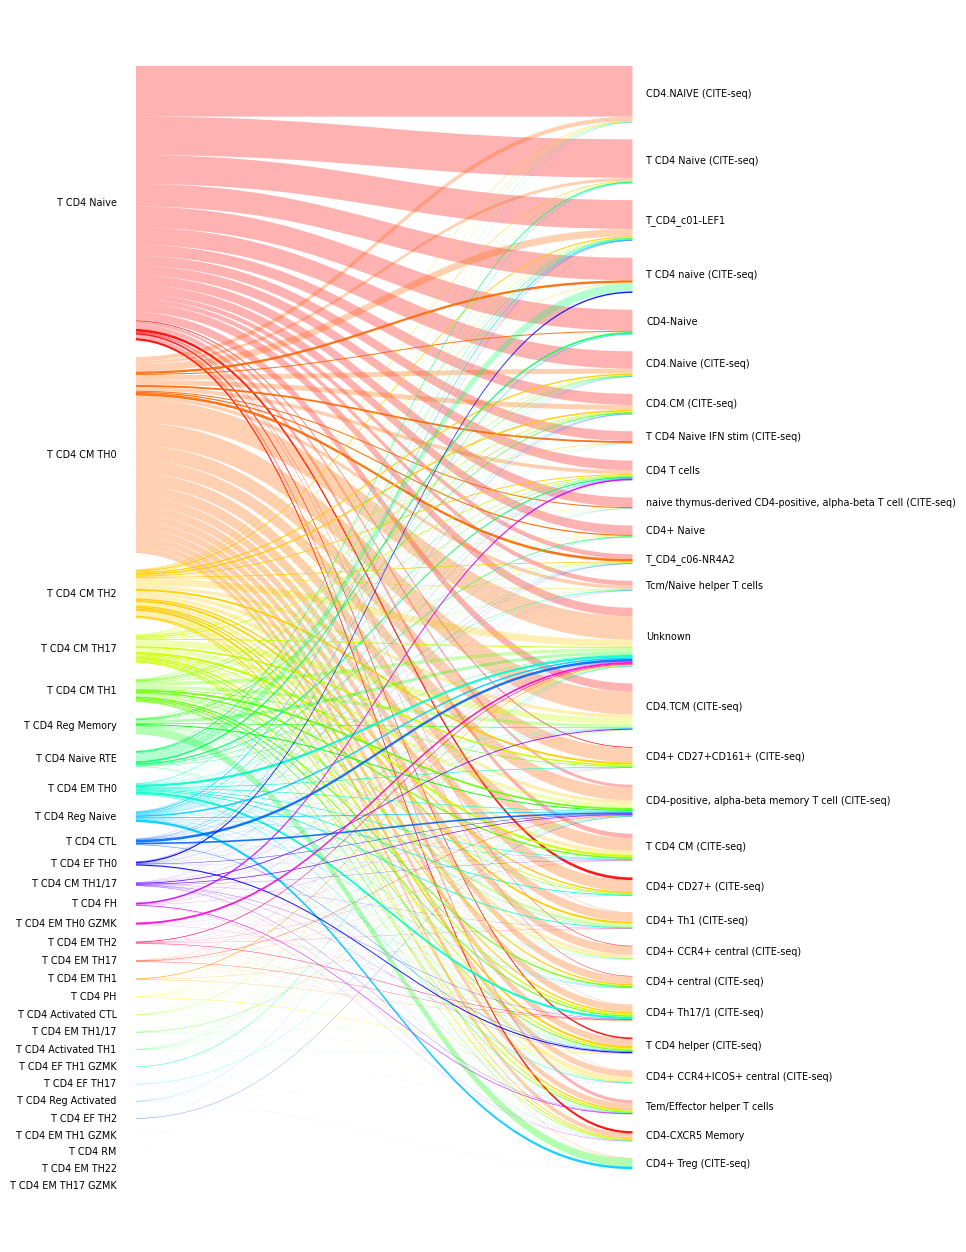

In [10]:
from sankey_KP import Sankey  # your custom Sankey class

# Copy relevant columns
obs = adata.obs[['annotation_level_3', 'author_annotation_with_CITE']].copy()

# Handle missing values
for col in ['annotation_level_3', 'author_annotation_with_CITE']:
    if pd.api.types.is_categorical_dtype(obs[col]):
        if "Unknown" not in obs[col].cat.categories:
            obs[col] = obs[col].cat.add_categories(["Unknown"])
    obs[col] = obs[col].fillna("Unknown")
    obs[col] = obs[col].replace(['nan', 'NaN', 'NAN'], "Unknown")

# Filter out rare categories instead of masking
plotting_threshold = 0.01  # 0.1%_
value_counts = obs['author_annotation_with_CITE'].value_counts(normalize=True)
keep_labels = value_counts[value_counts >= plotting_threshold].index

# Keep only cells with frequent categories
obs_filtered = obs[obs['author_annotation_with_CITE'].isin(keep_labels)].copy()

# Plot Sankey using the filtered dataframe
fig, ax = plt.subplots(figsize=(10, 16))
Sankey(
    x=obs_filtered["annotation_level_3"],
    y=obs_filtered["author_annotation_with_CITE"],
    ax=ax,
    fontsize="x-small",
    colorside="left"
).draw("left")

#plt.savefig(save_dir + "T_CD4_Sankey_author_annotation_wo_rare.pdf", dpi=200, bbox_inches="tight")#

- Ext Data Fig. 2b

In [11]:
TH1=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Hoellbacher/TH1_UP.csv')
TH1=TH1['geneSymbol'].to_list()

TH2=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Hoellbacher/TH2_UP.csv')
TH2=TH2['geneSymbol'].to_list()

TH17=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Hoellbacher/TH17_UP.csv')
TH17=TH17['geneSymbol'].to_list()

TH22=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Hoellbacher/TH22_UP.csv')
TH22=TH22['geneSymbol'].to_list()

In [12]:
sc.tl.score_genes(adata, gene_list=TH1, score_name='TH1_score')
sc.tl.score_genes(adata, gene_list=TH2, score_name='TH2_score')
sc.tl.score_genes(adata, gene_list=TH17, score_name='TH17_score')
sc.tl.score_genes(adata, gene_list=TH22, score_name='TH22_score')

       'KIAA1522', 'P3H3', 'PWP2', 'RTP5', 'RUSC2', 'SH3RF3', 'SRPK3',
       'TSPAN33', 'YARS', 'ZNF135', 'ZNF541'],
      dtype='object')
       'JAKMIP3', 'RBL1', 'SARAF'],
      dtype='object')
       'RPLP0'],
      dtype='object')
       'CFAP45', 'CIART', 'FAM65C', 'FGF18', 'GSG2', 'GYLTL1B', 'HIST1H3D',
       'KIAA0355', 'LMNTD2', 'MAP6', 'MARCH9', 'MB21D1', 'MMRN2', 'PDZD2',
       'PLXNB1', 'PRRC2B', 'SCO2', 'SEPT11', 'SGOL1', 'SLC16A2', 'SLC22A3',
       'SUSD6', 'TENM4', 'TMEM173', 'WHSC1', 'ZYG11A'],
      dtype='object')


In [13]:
adata.obs['TH1_score_Hoellbacher']=adata.obs['TH1_score']
del adata.obs['TH1_score']

adata.obs['TH2_score_Hoellbacher']=adata.obs['TH2_score']
del adata.obs['TH2_score']

adata.obs['TH17_score_Hoellbacher']=adata.obs['TH17_score']
del adata.obs['TH17_score']

adata.obs['TH22_score_Hoellbacher']=adata.obs['TH22_score']
del adata.obs['TH22_score']

In [14]:
TH1=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Schmiedel/T_CD4_Helper_1.txt')
TH1=TH1['geneSymbol'].to_list()

TH1_17=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Schmiedel/T_CD4_Helper_1_17.txt')
TH1_17=TH1_17['geneSymbol'].to_list()

TH17=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Schmiedel/T_CD4_Helper_17.txt')
TH17=TH17['geneSymbol'].to_list()

TH2=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Schmiedel/T_CD4_Helper_2.txt')
TH2=TH2['geneSymbol'].to_list()

TFH=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Schmiedel/T_CD4_Follicular_Helper.txt')
TFH=TFH['geneSymbol'].to_list()

Treg_CD45RApos=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Schmiedel/T_CD4_Naive_T_reg.txt')
Treg_CD45RApos=Treg_CD45RApos['geneSymbol'].to_list()

Treg_CD45RAneg=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Schmiedel/T_CD4_Memory_T_reg.txt')
Treg_CD45RAneg=Treg_CD45RAneg['geneSymbol'].to_list()

T_naive=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD4_TH_signatures/Schmiedel/T_CD4_Naive.txt')
T_naive=T_naive['geneSymbol'].to_list()

In [15]:
gene_lists = [T_naive, Treg_CD45RAneg, Treg_CD45RApos, TFH, TH2, TH17, TH1_17, TH1]
gene_list_names = ["T_naive", "Treg_CD45RAneg", "Treg_CD45RApos", "TFH", "TH2", "TH17", "TH1_17", "TH1"]

for subset, name in zip(gene_lists, gene_list_names):
    sc.tl.score_genes(adata, gene_list=subset, score_name=f"{name}_score_Schmiedel")

       'ADD2', 'DSC1', 'C4BPB', 'DACH1', 'NRCAM', 'KRT74', 'CA6', 'SEMA3A',
       'CCR12P', 'C21orf128', 'RP5-997D24.3', 'RP11-641A6.2', 'MMP28',
       'RP11-14I17.3', 'BANK1', 'TTTY14', 'LL0XNC01-131B10.2', 'CD248', 'XKRX',
       'STOX1', 'STARD4-AS1', 'snoU13', 'HNRNPA1P27', 'KRT128P',
       'RP11-140A10.3', 'ANKRD36BP2', 'TCL1A', 'MANSC1', 'RP11-401P9.4',
       'ZNF215', 'GIPC3', 'PAX5', 'TUBB3P2', 'NDST1', 'PARD3', 'LINC00563',
       'LRRC16A', 'ANXA9', 'CACHD1', 'TPTEP1', 'U8', 'CD22', 'RP11-61O1.1',
       'RP11-552E20.4', 'IGLV3-19', 'SIAH3', 'AKR1C2', 'REG4', 'BLZF2P',
       'CLEC17A', 'RP11-326C3.15', 'IGJ', 'PTGFRN', 'RP11-127L20.3', 'RASL10B',
       'ALDH7A1P3', 'PHYHD1', 'RNU6-242P', 'LINC00951', 'RP11-453F18__B.1',
       'RP11-474N24.6', 'AC144521.1', 'LRRC7', 'RP11-1020A11.1'],
      dtype='object')
       'RP11-356I2.1', 'AC002331.1', 'AC011997.1', 'ZC3H12C', 'CPE',
       ...
       'GS1-204I12.4', 'RP11-367G6.3', 'RP11-377G16.2', 'TEX14', 'SLC22A13',
       'R

/tmp/ipykernel_18158/1165721788.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata.obs.groupby('annotation_level_3')[['TH1_score_Hoellbacher', 'TH2_score_Hoellbacher', 'TH17_score_Hoellbacher', 'TH22_score_Hoellbacher', 'T_naive_score_Schmiedel', 'Treg_CD45RAneg_score_Schmiedel', 'Treg_CD45RApos_score_Schmiedel', 'TFH_score_Schmiedel', 'TH2_score_Schmiedel', 'TH17_score_Schmiedel', 'TH1_17_score_Schmiedel', 'TH1_score_Schmiedel']].mean()


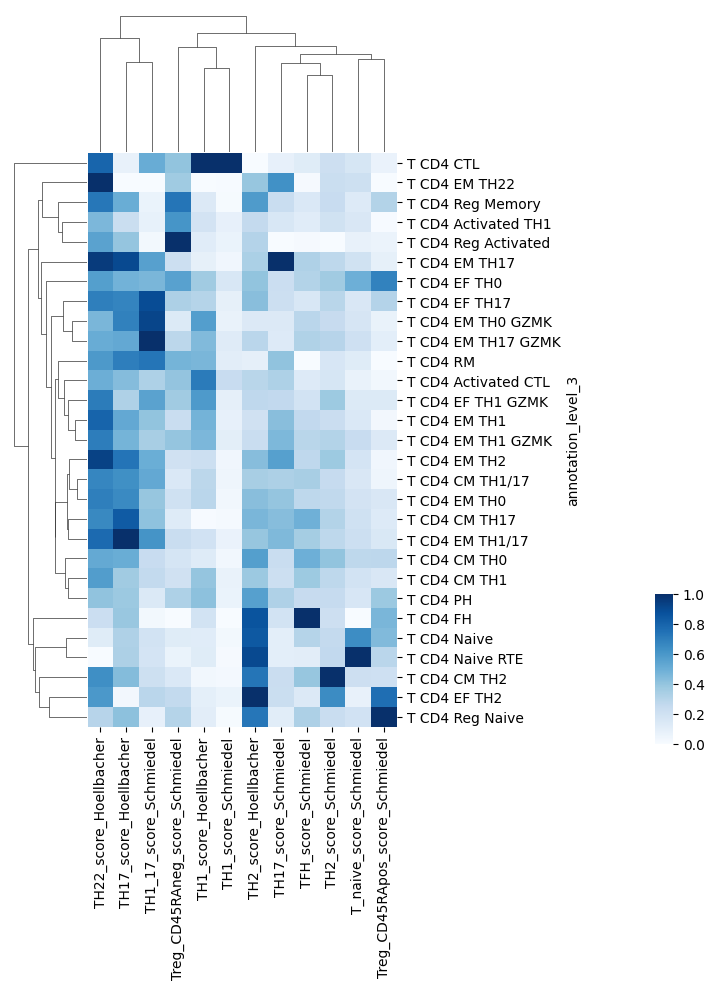

In [17]:
import seaborn as sns

# Compute group means
df = adata.obs.groupby('annotation_level_3')[['TH1_score_Hoellbacher', 'TH2_score_Hoellbacher', 'TH17_score_Hoellbacher', 'TH22_score_Hoellbacher', 'T_naive_score_Schmiedel', 'Treg_CD45RAneg_score_Schmiedel', 'Treg_CD45RApos_score_Schmiedel', 'TFH_score_Schmiedel', 'TH2_score_Schmiedel', 'TH17_score_Schmiedel', 'TH1_17_score_Schmiedel', 'TH1_score_Schmiedel']].mean()

# Clustermap
g = sns.clustermap(
    df,
    cmap="Blues",
    standard_scale=1,
    figsize=(6, 10),
    cbar_pos=(1.1, 0.25, 0.03, 0.15)
)

#g.savefig(save_dir+'T_CD4_gene_scores.pdf')
#g.show()

- Ext Data Fig. 2c

In [18]:
work_dir='/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/Multi_milo/Manuscript_final/'

In [19]:
from __future__ import annotations
from pathlib import Path
from typing import Optional, Sequence, Dict, Tuple, Union
import os
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def plot_multi_milo(
    compare_variable: str,
    annotation: str,
    milo_dir: Union[str, Path],
    exp_df: Union[str, Path, pd.DataFrame],
    cell_type: str = "CD4",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    group_of_interest: Optional[str] = None,
    only_show_group_of_interest: bool = False,
    savedir: Optional[Union[str, Path]] = None,
    significant_only: bool = True,
    sig_thresh: float = 0.20,
    sig_thresh_strict: float = 0.10,
    sig_star: bool = False,
    blood_only: bool = False,
    ignore_groups: Optional[Sequence[str]] = None,
    add_filter: Optional[Tuple[str, str]] = None,
    drop_duplicates: bool = False,
    df_filter_exclude_annotation: Sequence[str] = ("Mixed",),
    tissue_colors: Optional[Dict[str, str]] = None,
    group_palette: Optional[Sequence] = None,
    cmap: str = "bwr",
    center: float = 0.0,
    col_cluster: bool = True,
    row_cluster: bool = True,
    row_order: Optional[Sequence] = None,
    col_order: Optional[Sequence[str]] = None,
    figure_size: Tuple[int, int] = None,
    return_objects: bool = True,
) -> Optional[Tuple[sns.matrix.ClusterGrid, pd.DataFrame, pd.DataFrame]]:
    """
    Plot a Milo-style clustermap of per-experiment cell-state enrichment/depletion.

    Row labels show the pathogen name derived from the `group_1` column of exp_df,
    with underscores replaced by spaces for readability:
      "Plasmodium_falciparum" -> "Plasmodium falciparum"
      "SARS_CoV_2"            -> "SARS CoV 2"
      "HIV_acute"             -> "HIV acute"

    row_order : sequence, optional
        Custom order for rows (experiment IDs). If provided, disables row clustering.
    col_order : sequence of str, optional
        Custom order for columns (nhood_annotation). If provided, disables column clustering.
    cell_type : str, optional
        Cell type to load results for. Either "CD4" or "CD8". Default is "CD4".
    vmin : float, optional
        Minimum value for colormap scaling. If None, uses data min.
    vmax : float, optional
        Maximum value for colormap scaling. If None, uses data max.
    """
    logging.getLogger(__name__).setLevel(logging.INFO)

    milo_dir = Path(milo_dir)
    summary_dir = milo_dir / annotation

    if isinstance(exp_df, (str, Path)):
        experiment_df = pd.read_csv(exp_df)
    else:
        experiment_df = exp_df.copy()

    # Basic input checks
    required_cols = {"id", "compare_variable", "group_1", "group_2"}
    missing = required_cols - set(experiment_df.columns)
    if missing:
        raise ValueError(f"exp_df is missing required columns: {sorted(missing)}")

    experiment_df = experiment_df[experiment_df["compare_variable"] == compare_variable].copy()

    if drop_duplicates and "subset_condition" in experiment_df.columns:
        experiment_df = experiment_df.drop_duplicates(subset="subset_condition")

    if add_filter is not None:
        key, val = add_filter
        if key not in experiment_df.columns:
            raise KeyError(f"add_filter key '{key}' not found in exp_df columns")
        experiment_df = experiment_df[experiment_df[key] == val]

    if only_show_group_of_interest:
        experiment_df = experiment_df[
            experiment_df["group_1"].eq(group_of_interest) | experiment_df["group_2"].eq(group_of_interest)
        ]

    if ignore_groups:
        ig = set(ignore_groups)
        experiment_df = experiment_df[
            ~experiment_df["group_1"].isin(ig) & ~experiment_df["group_2"].isin(ig)
        ]

    # Build id -> pathogen label mapping directly from group_1 in experiment_df.
    # Underscores are replaced with spaces for readability.
    # e.g. "Plasmodium_falciparum" -> "Plasmodium falciparum"
    #      "SARS_CoV_2"            -> "SARS CoV 2"
    #      "HIV_acute"             -> "HIV acute"
    #      "Bacterial_infection"   -> "Bacterial infection"
    id_to_label: Dict[str, str] = {
        row["id"]: str(row["group_1"]).replace("_", " ")
        for _, row in experiment_df.iterrows()
    }

    all_results = []
    all_results_full = []
    selected_meta_rows = []

    if tissue_colors is None:
        tissue_colors = {"PBMCs": "firebrick", "non-PBMCs": "#999999"}

    for _, row in experiment_df.iterrows():
        eid = row["id"]
        summary_path = summary_dir / f"results_{cell_type}_{eid}.csv"
        if not summary_path.exists():
            logging.warning(f"Missing file: {summary_path.name}")
            continue

        df = pd.read_csv(summary_path)
        missing_cols = {"nhood_annotation", "logFC", "SpatialFDR"} - set(df.columns)
        if missing_cols:
            logging.warning(f"{summary_path.name} missing columns: {sorted(missing_cols)}; skipping.")
            continue

        df["experiment_id"] = eid

        # Flip logFC to ensure consistent interpretation for group_of_interest.
        flipped = False
        if group_of_interest is not None:
            if group_of_interest == "Healthy":
                if row["group_1"] == group_of_interest:
                    df["logFC"] = -df["logFC"]
                    flipped = True
            else:
                if row["group_2"] == group_of_interest:
                    df["logFC"] = -df["logFC"]
                    flipped = True

        meta_row = row.copy()
        meta_row["id"] = eid
        if flipped:
            meta_row["group_1"], meta_row["group_2"] = meta_row["group_2"], meta_row["group_1"]
        selected_meta_rows.append(meta_row)

        if significant_only:
            df = df[df["SpatialFDR"] < sig_thresh].copy()

        if df_filter_exclude_annotation:
            df = df[~df["nhood_annotation"].isin(df_filter_exclude_annotation)]

        if df.empty:
            continue

        all_results.append(df[["experiment_id", "nhood_annotation", "logFC"]])
        if sig_star:
            all_results_full.append(df[["experiment_id", "nhood_annotation", "logFC", "SpatialFDR"]])

    if not all_results:
        logging.warning("No results to plot after filtering; nothing to do.")
        return None if not return_objects else (None, pd.DataFrame(), pd.DataFrame())

    # Build matrix and meta
    results_df = pd.concat(all_results, ignore_index=True)
    matrix = (
        results_df.pivot(index="experiment_id", columns="nhood_annotation", values="logFC")
        .fillna(0.0)
    )
    # Drop rows that are all zeros (no retained neighborhoods for that experiment)
    matrix = matrix.loc[~(matrix == 0).all(axis=1)]
    if matrix.empty:
        logging.warning("LogFC matrix is empty after zero-row removal; nothing to plot.")
        return None if not return_objects else (None, matrix, pd.DataFrame())

    # Apply custom ordering if provided
    if row_order is not None:
        valid_rows = [r for r in row_order if r in matrix.index]
        if not valid_rows:
            logging.warning("No valid row_order IDs found in matrix; ignoring row_order")
        else:
            matrix = matrix.loc[valid_rows]
            row_cluster = False

    if col_order is not None:
        valid_cols = [c for c in col_order if c in matrix.columns]
        if not valid_cols:
            logging.warning("No valid col_order annotations found in matrix; ignoring col_order")
        else:
            matrix = matrix[valid_cols]
            col_cluster = False

    meta = pd.DataFrame(selected_meta_rows).set_index("id").loc[matrix.index].copy()

    # --- Color mapping for groups ---
    group_vals = pd.unique(meta[["group_1", "group_2"]].values.ravel("K"))
    group_vals = [g for g in group_vals if pd.notna(g)]
    if "Healthy" in group_vals:
        group_vals = ["Healthy"] + sorted([g for g in group_vals if g != "Healthy"])
    else:
        group_vals = sorted(group_vals)

    if group_palette is None:
        group_palette = sns.color_palette("tab20", n_colors=max(len(group_vals), 3))
    group_colors = dict(zip(group_vals, group_palette))

    row_colors = pd.DataFrame(
        {
            "Group 1": meta["group_1"].map(group_colors),
            "Group 2": meta["group_2"].map(group_colors),
        },
        index=matrix.index,
    )

    if figure_size is not None:
        figsize = figure_size
    else:
        if matrix.shape[0] < 5:
            figsize = (7, 6)
        else:
            figsize = (10, 10)

    g = sns.clustermap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        row_colors=row_colors,
        cmap=cmap,
        center=center,
        figsize=figsize,
        xticklabels=True,
        yticklabels=False,
        col_cluster=col_cluster,
        row_cluster=row_cluster,
        cbar_kws={'label': 'logFC'},
        cbar_pos=(1.12, 0.2, 0.03, 0.3),
    )

    # Optional significance overlay
    if sig_star and all_results_full:
        full_df = pd.concat(all_results_full, ignore_index=True)

        full_matrix = (
            full_df.pivot(index="experiment_id", columns="nhood_annotation", values="logFC")
            .reindex(index=matrix.index, columns=matrix.columns)
        )
        fdr = full_df.pivot(index="experiment_id", columns="nhood_annotation", values="SpatialFDR")
        fdr = fdr.reindex_like(full_matrix)

        sig_mask_loose = fdr < sig_thresh
        sig_mask_strict = fdr < sig_thresh_strict

        if row_order is not None and col_order is not None:
            row_order_plot = [r for r in row_order if r in matrix.index]
            col_order_plot = [c for c in col_order if c in matrix.columns]
        elif row_order is not None:
            row_order_plot = [r for r in row_order if r in matrix.index]
            col_order_plot = [full_matrix.columns[i] for i in g.dendrogram_col.reordered_ind]
        elif col_order is not None:
            row_order_plot = [full_matrix.index[i] for i in g.dendrogram_row.reordered_ind]
            col_order_plot = [c for c in col_order if c in matrix.columns]
        else:
            row_order_plot = [full_matrix.index[i] for i in g.dendrogram_row.reordered_ind]
            col_order_plot = [full_matrix.columns[i] for i in g.dendrogram_col.reordered_ind]

        ax = g.ax_heatmap
        for i, rid in enumerate(row_order_plot):
            for j, cid in enumerate(col_order_plot):
                if pd.notna(sig_mask_loose.loc[rid, cid]) and sig_mask_loose.loc[rid, cid]:
                    mark = "*" if (pd.notna(sig_mask_strict.loc[rid, cid]) and sig_mask_strict.loc[rid, cid]) else "°"
                    ax.text(j + 0.5, i + 0.5, mark, ha="center", va="center", color="black", fontsize=12)



    # --- Y-axis labels: use pathogen name (from group_1) instead of experiment ID ---
    if row_order is not None:
        reordered_index = [r for r in row_order if r in matrix.index]
    else:
        reordered_index = list(matrix.index[g.dendrogram_row.reordered_ind])

    reordered_labels = [id_to_label.get(eid, str(eid)) for eid in reordered_index]

    g.ax_heatmap.set_yticks(np.arange(len(reordered_labels)) + 0.5)
    g.ax_heatmap.set_yticklabels(reordered_labels)

    plt.suptitle(f"FDR: {sig_thresh} > ° > {sig_thresh_strict} > *, {annotation}", y=1.05)
    plt.tight_layout()

    if savedir is not None:
        savedir = Path(savedir)
        g.savefig(savedir, bbox_inches="tight")

    plt.show()

/tmp/ipykernel_18158/2500124414.py:293: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


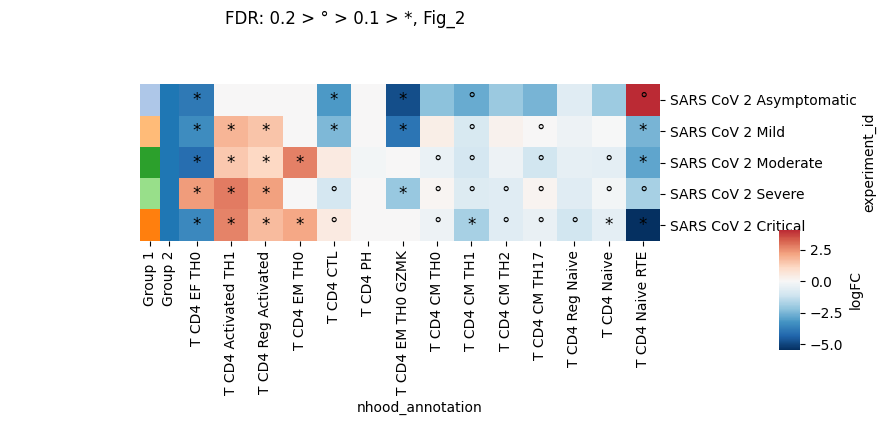

In [20]:
custom_row_order=[0,1,2,3,4]
#custom_col_order=['T CD4 Naive','T CD4 Naive RTE','T CD4 CM TH0','T CD4 CM TH1','T CD4 CM TH2','T CD4 CM TH17','T CD4 EM TH0','T CD4 EM TH0 GZMK','T CD4 EF TH0','T CD4 CTL','T CD4 Activated TH1','T CD4 FH','T CD4 PH','T CD4 Reg Naive','T CD4 Reg Activated']
custom_col_order=['T CD4 EF TH0','T CD4 Activated TH1','T CD4 Reg Activated','T CD4 EM TH0','T CD4 CTL','T CD4 PH','T CD4 FH','T CD4 EM TH0 GZMK','T CD4 CM TH0','T CD4 CM TH1','T CD4 CM TH2','T CD4 CM TH17','T CD4 Reg Naive','T CD4 Naive','T CD4 Naive RTE']

plot_multi_milo(compare_variable='severity_stage_detail2',
                milo_dir=work_dir,
                cell_type='CD4',
                significant_only=False,
                figure_size=(7,4),
                annotation='Fig_2',
                exp_df=work_dir+'milo_experiment_plan_CD4_fig2.csv',
                sig_star=True,
                row_order=custom_row_order,
                col_order=custom_col_order,
                cmap='RdBu_r',
                sig_thresh=0.2)